# Part 3: Quantization-Aware Training (QAT)

## 이 노트북에서 다루는 내용
1. QAT 개념 (Fake Quantization, Straight-Through Estimator)
2. QAT 적용 및 학습
3. QAT vs Static PTQ 비교
4. QAT Fine-tuning 에포크별 효과

## QAT 핵심 개념

### Fake Quantization
- Forward: `x_fq = dequant(quant(x))` → 양자화 오차를 학습 중 경험
- Backward: Straight-Through Estimator (STE) → round 함수의 gradient를 1로 근사

### 왜 QAT가 PTQ보다 나은가?
- **PTQ**: 학습 완료 후 양자화 → 모델이 양자화 오차에 **적응하지 못함**
- **QAT**: 학습 중 양자화 시뮬레이션 → 모델이 양자화 오차에 **적응**

### Pipeline
```
FP32 모델 학습 → QuantizableCNN에 가중치 로드
→ fuse_model() → QAT qconfig → prepare_qat()
→ QAT Fine-tuning → convert() → INT8 모델
```

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import copy
import time
import tempfile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.ao.quantization as quant
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN, QuantizableCNN

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
BATCH_SIZE = 128
EPOCHS = 10
QAT_EPOCHS = 5
LEARNING_RATE = 0.001
QAT_LEARNING_RATE = 0.0001
NUM_CLASSES = 10
SEED = 42
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습: {len(train_dataset):,}, 테스트: {len(test_dataset):,}")

학습: 50,000, 테스트: 10,000


## [2] 유틸리티 함수

In [3]:
def train_model(model, train_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


def train_qat(model, train_loader, epochs, learning_rate):
    """QAT 학습 (CPU)"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"QAT Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return epoch_losses


def test_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def get_model_size_mb(model):
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.pth')
    tmp_path = tmp.name
    tmp.close()
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb


def measure_inference_time(model, test_loader, device, num_batches=50):
    model.to(device)
    model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= 5: break
            _ = model(inputs.to(device))
    start = time.time()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= num_batches: break
            _ = model(inputs.to(device))
    return time.time() - start


def load_cnn_weights_to_quantizable(fp32_state_dict, num_classes=10):
    """CNN → QuantizableCNN 가중치 매핑"""
    qmodel = QuantizableCNN(num_classes=num_classes)
    quant_sd = {}
    for key, value in fp32_state_dict.items():
        if key.startswith('features.'):
            quant_sd[key] = value
        elif key == 'classifier.0.weight':
            quant_sd['classifier.0.weight'] = value
        elif key == 'classifier.0.bias':
            quant_sd['classifier.0.bias'] = value
        elif key == 'classifier.3.weight':
            quant_sd['classifier.2.weight'] = value
        elif key == 'classifier.3.bias':
            quant_sd['classifier.2.bias'] = value
    qmodel.load_state_dict(quant_sd)
    return qmodel

## [3] Baseline 모델 학습

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES)
train_model(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)

model.to(DEVICE)
baseline_acc = test_model(model, test_loader, DEVICE)
baseline_size = get_model_size_mb(model)
print(f"\nBaseline 정확도: {baseline_acc:.2f}%")
print(f"Baseline 크기: {baseline_size:.2f} MB")

fp32_state_dict = copy.deepcopy(model.cpu().state_dict())

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347

Baseline 정확도: 75.01%
Baseline 크기: 4.53 MB


## [4] Static PTQ (비교 기준)

In [5]:
static_model = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)
static_model.eval()
static_model.fuse_model()
static_model.qconfig = quant.get_default_qconfig('fbgemm')
quant.prepare(static_model, inplace=True)

print("Calibration 진행 중...")
with torch.no_grad():
    for i, (inputs, _) in enumerate(train_loader):
        if i >= 100: break
        static_model(inputs)

quant.convert(static_model, inplace=True)

static_acc = test_model(static_model, test_loader, 'cpu')
static_size = get_model_size_mb(static_model)
print(f"\nStatic PTQ 정확도: {static_acc:.2f}%")
print(f"Static PTQ 크기: {static_size:.2f} MB")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Calibration 진행 중...

Static PTQ 정확도: 74.90%
Static PTQ 크기: 1.16 MB


## [5] QAT (Quantization-Aware Training)

Fake Quantization 노드를 삽입하여 학습 중 양자화 효과를 시뮬레이션합니다.

In [6]:
# QAT 모델 준비
qat_model = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)

# train 모드에서 fuse_model (QAT는 train 모드에서 prepare)
qat_model.train()
qat_model.fuse_model()

# QAT qconfig (Fake Quantization observer 포함)
qat_model.qconfig = quant.get_default_qat_qconfig('fbgemm')

# prepare_qat: Fake Quantization 노드 삽입
quant.prepare_qat(qat_model, inplace=True)

print("Fake Quantization 노드 삽입 완료")
print(f"\nQAT 학습 시작 ({QAT_EPOCHS} epochs, LR={QAT_LEARNING_RATE})...")

Fake Quantization 노드 삽입 완료

QAT 학습 시작 (5 epochs, LR=0.0001)...


In [7]:
# QAT Fine-tuning (CPU에서)
qat_losses = train_qat(qat_model, train_loader, QAT_EPOCHS, QAT_LEARNING_RATE)

# Fake Quantization 상태에서 정확도 확인
fq_acc = test_model(qat_model, test_loader, 'cpu')
print(f"\nFake Quantization 상태 정확도: {fq_acc:.2f}%")

QAT Epoch 1/5, Loss: 0.0250
QAT Epoch 2/5, Loss: 0.0056
QAT Epoch 3/5, Loss: 0.0022
QAT Epoch 4/5, Loss: 0.0011
QAT Epoch 5/5, Loss: 0.0006

Fake Quantization 상태 정확도: 77.24%


In [8]:
# 실제 INT8로 변환
qat_model.eval()
qat_quantized = quant.convert(qat_model)

qat_acc = test_model(qat_quantized, test_loader, 'cpu')
qat_size = get_model_size_mb(qat_quantized)

print(f"\nQAT 최종 정확도: {qat_acc:.2f}%")
print(f"QAT 크기: {qat_size:.2f} MB")
print(f"크기 감소율: {(1 - qat_size / baseline_size) * 100:.1f}%")


QAT 최종 정확도: 77.23%
QAT 크기: 1.16 MB
크기 감소율: 74.4%


## [6] QAT 에포크별 효과 실험

In [9]:
epoch_results = []

for ep in [1, 3, 5, 10]:
    print(f"\n--- QAT {ep} epochs ---")
    m = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)
    m.train()
    m.fuse_model()
    m.qconfig = quant.get_default_qat_qconfig('fbgemm')
    quant.prepare_qat(m, inplace=True)
    train_qat(m, train_loader, ep, QAT_LEARNING_RATE)
    m.eval()
    m = quant.convert(m)
    acc = test_model(m, test_loader, 'cpu')
    epoch_results.append((ep, acc))
    print(f"→ 정확도: {acc:.2f}%")

print("\n에포크별 결과:")
for ep, acc in epoch_results:
    print(f"  {ep} epochs → {acc:.2f}%")


--- QAT 1 epochs ---
QAT Epoch 1/1, Loss: 0.0250
→ 정확도: 76.79%

--- QAT 3 epochs ---
QAT Epoch 1/3, Loss: 0.0249
QAT Epoch 2/3, Loss: 0.0056
QAT Epoch 3/3, Loss: 0.0022
→ 정확도: 77.06%

--- QAT 5 epochs ---
QAT Epoch 1/5, Loss: 0.0246
QAT Epoch 2/5, Loss: 0.0054
QAT Epoch 3/5, Loss: 0.0022
QAT Epoch 4/5, Loss: 0.0011
QAT Epoch 5/5, Loss: 0.0006
→ 정확도: 77.12%

--- QAT 10 epochs ---
QAT Epoch 1/10, Loss: 0.0253
QAT Epoch 2/10, Loss: 0.0055
QAT Epoch 3/10, Loss: 0.0023
QAT Epoch 4/10, Loss: 0.0011
QAT Epoch 5/10, Loss: 0.0007
QAT Epoch 6/10, Loss: 0.0004
QAT Epoch 7/10, Loss: 0.0003
QAT Epoch 8/10, Loss: 0.0002
QAT Epoch 9/10, Loss: 0.0001
QAT Epoch 10/10, Loss: 0.0001
→ 정확도: 77.32%

에포크별 결과:
  1 epochs → 76.79%
  3 epochs → 77.06%
  5 epochs → 77.12%
  10 epochs → 77.32%


## [7] 추론 시간 비교

In [10]:
model_cpu = copy.deepcopy(model).cpu()
baseline_time = measure_inference_time(model_cpu, test_loader, 'cpu')
static_time = measure_inference_time(static_model, test_loader, 'cpu')
qat_time = measure_inference_time(qat_quantized, test_loader, 'cpu')

print(f"Baseline (FP32): {baseline_time:.3f}초")
print(f"Static PTQ:      {static_time:.3f}초")
print(f"QAT:             {qat_time:.3f}초")

Baseline (FP32): 4.437초
Static PTQ:      1.703초
QAT:             1.781초


## [8] 결과 시각화

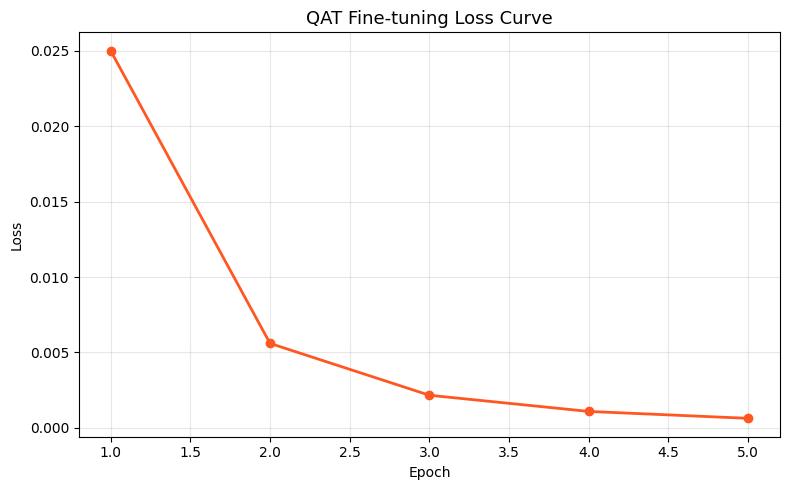

In [11]:
# QAT 학습 곡선
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(qat_losses)+1), qat_losses, 'o-', color='#FF5722', linewidth=2, markersize=6)
ax.set_title('QAT Fine-tuning Loss Curve', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

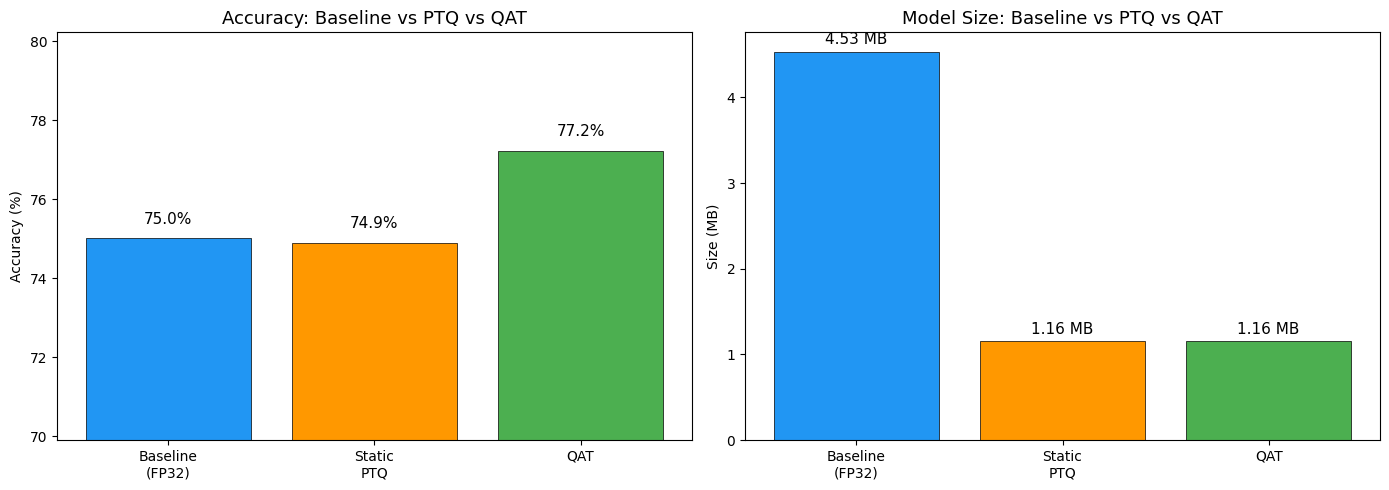

In [12]:
# Baseline vs PTQ vs QAT 비교
methods = ['Baseline\n(FP32)', 'Static\nPTQ', 'QAT']
accs = [baseline_acc, static_acc, qat_acc]
sizes = [baseline_size, static_size, qat_size]
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(methods, accs, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Accuracy: Baseline vs PTQ vs QAT', fontsize=13)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(min(accs) - 5, max(accs) + 3)
for bar, acc in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11)

bars2 = ax2.bar(methods, sizes, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Model Size: Baseline vs PTQ vs QAT', fontsize=13)
ax2.set_ylabel('Size (MB)')
for bar, s in zip(bars2, sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{s:.2f} MB', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

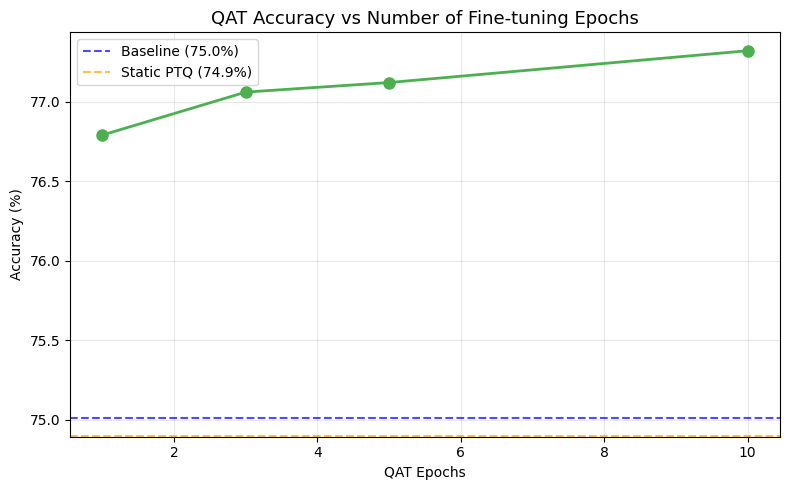

In [13]:
# 에포크별 결과
fig, ax = plt.subplots(figsize=(8, 5))
ep_list, ep_accs = zip(*epoch_results)
ax.plot(ep_list, ep_accs, 'o-', color='#4CAF50', linewidth=2, markersize=8)
ax.axhline(y=baseline_acc, color='blue', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_acc:.1f}%)')
ax.axhline(y=static_acc, color='orange', linestyle='--', alpha=0.7, label=f'Static PTQ ({static_acc:.1f}%)')
ax.set_title('QAT Accuracy vs Number of Fine-tuning Epochs', fontsize=13)
ax.set_xlabel('QAT Epochs')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 결과 요약

In [14]:
print("=" * 60)
print("QAT 결과 요약")
print("=" * 60)
print(f"{'Method':<25} {'Accuracy':>10} {'Size (MB)':>10} {'Speed':>10}")
print("-" * 55)
print(f"{'Baseline (FP32)':<25} {baseline_acc:>9.2f}% {baseline_size:>9.2f} {baseline_time:>9.3f}s")
print(f"{'Static PTQ':<25} {static_acc:>9.2f}% {static_size:>9.2f} {static_time:>9.3f}s")
print(f"{'QAT':<25} {qat_acc:>9.2f}% {qat_size:>9.2f} {qat_time:>9.3f}s")
print(f"\nQAT 에포크별 정확도:")
for ep, acc in epoch_results:
    print(f"  {ep} epochs → {acc:.2f}%")
print(f"\nQAT는 학습 중 양자화를 시뮬레이션하여")
print(f"PTQ 대비 정확도 손실을 줄일 수 있습니다.")

QAT 결과 요약
Method                      Accuracy  Size (MB)      Speed
-------------------------------------------------------
Baseline (FP32)               75.01%      4.53     4.437s
Static PTQ                    74.90%      1.16     1.703s
QAT                           77.23%      1.16     1.781s

QAT 에포크별 정확도:
  1 epochs → 76.79%
  3 epochs → 77.06%
  5 epochs → 77.12%
  10 epochs → 77.32%

QAT는 학습 중 양자화를 시뮬레이션하여
PTQ 대비 정확도 손실을 줄일 수 있습니다.
